# 16. Every checkpoint, the same checks, on the same cubes

Until now each checkpoint family had its own scoring script with its own preprocessing, so no two
checkpoints had ever been put through the same tests. This notebook runs **one protocol over every checkpoint it
can find** (`src/evaluation/checkpoint_eval.py`) and compares them.

| check | what it shows | how |
|---|---|---|
| pixel | PSNR / SSIM | per channel on the shared dirty-scale normalisation, clamped to [0, 1] |
| moments | does it recover the physical quantities | `moment_improvement`: M0/M1/M2 over dirty, clipped + signal-masked |
| wiggle | does the kinematic signal survive | quadratic-M1 Keplerian residual, correlation with clean, ONE shared geometry per cube. The fit starts from the emission's shape and, on line-emission cubes, holds the inclination at its true `.para` value. A failed fit (centre off the disk, mass pinned) is flagged `geom_ok = False` and its wiggle numbers are blanked, not averaged in |
| sharpness | is the smoothing real | gradient energy and Laplacian variance of the raw M1, as a ratio to clean's (1.0 = as sharp as truth) |
| artifacts | did it trade smoothing for invented structure | invented-structure rate, blob count, overshoot, floor leak (`channel_artifacts`) |
| figures | what the recovered disk looks like | EVERY checkpoint tiled next to clean and dirty on one colour scale: moments, error maps, the wiggle residual, line-peak channels, sharpness, invented structure, spectra, radial profile and power spectrum, plus a detail figure for the best ones |
| transfer | real physics or one-domain overfit | the same call on SG cubes for line-emission models and the reverse |
| headroom | where each checkpoint sits on the degradation-vs-gain curve | (dirty resid_r, gain) is in every row |

**Everything is an image.** Besides the sheets below, each case also gets the integrated line spectrum (flux conserved at every
velocity?), a calibration plot (denoised against clean pixel by pixel, where smoothing shows as shrunk peaks), error histograms, and an
ensemble / disagreement figure (where the checkpoints agree, and whether averaging them helps). Section 6 builds, for every case, side-by-side sheets of ALL checkpoints (about 20 figures per
case), and for the whole run the score tables as heat-coloured images, a scoreboard of every metric, the loss x source
matrix (Jason's asks 1 and 3), and a checkpoint x cube heatmap. Colour scales come from clean (or from dirty's own error),
never from a checkpoint, so no tile looks better by being scaled differently.

**Cases.** 5 held-out line-emission cubes (RunIDs 0002 x3, 0025, 0026), the SG v2 cube (channels 240-360), and the SG
holdout disk `run_9074_00025_rt_00` (inclination fixed at its true 20 degrees).

**A warning about wiggle numbers from earlier scripts.** `score_08_kinematic.py` and most `experiments/` scripts call
`fit_keplerian` without `m0=`, so the fit starts from the mask's shape. On two of the five line-emission cubes that ran the
centre to the image edge (cy = 600.0). This notebook does not do that, so its wiggle numbers will differ from the published
nb08 ones on those cubes. See `results/PROGRESS.md` 2026-09-25.

**Validated before it was written (moments only; the wiggle protocol above is new):** on `run_0002_00560_rt_00` the harness gives `winner_aug_seed43` M0 +31.3,
M1 +77.2, M2 +84.6, identical to the published v20 numbers for that checkpoint and cube.

**How to read it.**
- Metrics are per (checkpoint, cube). Tables report the mean across cubes and the spread ACROSS CUBES, not
  across seeds (RULES.md #6). Most arms are a single seed.
- **`val_loss` is never compared.** It has a different scale for every objective (RULES.md #4). Rank on the metrics above.
- **PSNR does not rank.** It is here so that fact stays visible. Where PSNR and the moments disagree, believe the moments.
- **Dirty is the baseline that matters.** On a cube where dirty already sits high on the wiggle, no model can gain. The
  headroom figure is how to read a checkpoint without blaming it for a cube it could not have won.
- **Intensity scale.** The SG v2 cube's dirty is ~336x its clean. Where the two differ by more than 0.8 to 1.25x, clean is rescaled to the
  input's units (`amp_scale` in every row, on every amplitude figure). Velocity checks (M1, wiggle) never depended on it; the line-emission cubes
  are at 1.01 and are left untouched.
- **Continuum subtraction.** Every case is continuum-subtracted. Checkpoints trained without it (the SG family) get the
  same cube; on SG data that is a no-op, on line-emission cubes it is the closest available input.
- **DDRM checkpoints are not scored** (they restore through the beam operator, which is not wired into this protocol);
  the inventory lists them with that reason. Diffusion (DDPM) checkpoints run on `DIFFUSION_CASES` only (about 100x a U-Net forward).

**Attach:** `line-emission-data`, `self-gravitating-v2`, `exxa-sg-synth-pairs`, every checkpoint source
(`exxa-13-checkpoint-sources`, `exxa-14-checkpoint-sources`, `exxa-05-v38-recovered`), the Output of notebooks **05** and
**13** (their arms), and, on later sessions, this notebook's own previous Output (resume). GPU T4.

## 0. Bootstrap

In [1]:
import os, sys, subprocess, glob, re, time, shutil, csv, json

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
if ON_KAGGLE:
    REPO = '/kaggle/working/EXXA'; PKG = os.path.join(REPO, 'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch',BRANCH,'--depth','1',
                        'https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps',
                    'pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks')); sys.path.insert(0, PKG)
    WORK = '/kaggle/working'

    run_re = re.compile(r'run_\d+_\d+_rt_\d+', re.I)
    roots = {}
    for p in glob.glob('/kaggle/input/**/run_*', recursive=True):
        if os.path.isdir(p) and run_re.search(os.path.basename(p)):
            roots[os.path.dirname(p)] = roots.get(os.path.dirname(p), 0) + 1
    # line emission cubes are run_00xx_*; SG cubes are run_9xxx_*. The data dir is the folder holding the
    # most NON-SG run folders.
    le_roots = {}
    for p in glob.glob('/kaggle/input/**/run_0*', recursive=True):
        if os.path.isdir(p) and run_re.search(os.path.basename(p)):
            le_roots[os.path.dirname(p)] = le_roots.get(os.path.dirname(p), 0) + 1
    if not le_roots:
        raise FileNotFoundError('No run_00xx_* folders under /kaggle/input. Attach the line-emission Dataset.')
    DATA_DIR = max(le_roots, key=le_roots.get)
    _v2 = [p for p in glob.glob('/kaggle/input/**/clean_sg.fits', recursive=True) if os.path.isfile(p)]
    SG_V2_DIR = os.path.dirname(_v2[0]) if _v2 else None
    _h = [p for p in glob.glob('/kaggle/input/**/run_9074_00025_rt_00', recursive=True) if os.path.isdir(p)]
    SG_HOLD_DIR = _h[0] if _h else None
    CKPT_ROOTS = ['/kaggle/input']
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'):
        os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    WORK = os.path.abspath('../results/_nb16_scratch'); os.makedirs(WORK, exist_ok=True)
    DATA_DIR = '../Line Emission Data'
    SG_V2_DIR = '../self-gravitating cube and dirty cube/kinematic_data_v2'
    SG_HOLD_DIR = '../self-gravitating cube and dirty cube/sg_synth/run_9074_00025_rt_00'
    CKPT_ROOTS = ['../models/best_models']

print('DATA_DIR    :', DATA_DIR)
print('SG_V2_DIR   :', SG_V2_DIR or 'NOT FOUND, sg_v2 case skipped')
print('SG_HOLD_DIR :', SG_HOLD_DIR or 'NOT FOUND, sg holdout case skipped')

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5565/5565), done.


DATA_DIR    : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
SG_V2_DIR   : /kaggle/input/datasets/krishanyadav333/self-gravitating-v2/kinematic_data_v2
SG_HOLD_DIR : /kaggle/input/datasets/krishanyadav333/exxa-sg-synth-pairs/kaggle-sg-training-dataset/run_9074_00025_rt_00


## 0b. Pull latest `src` (re-run anytime, no restart needed)

In [2]:
if ON_KAGGLE:
    subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
    subprocess.run(['git','-C',REPO,'reset','--hard','FETCH_HEAD'], check=True)
    print(subprocess.run(['git','-C',REPO,'log','--oneline','-1'], capture_output=True, text=True).stdout)
    import importlib, src; importlib.reload(src)
assert os.path.exists('../src/evaluation/checkpoint_eval.py'), 'checkpoint_eval.py missing: wrong branch pulled? RULES.md #9'

From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


HEAD is now at 6e4e139 docs: archive 05 v47 (first valid 320/480 scores), blog section 2 answered
6e4e139 docs: archive 05 v47 (first valid 320/480 scores), blog section 2 answered



## 1. Config

`PROFILE` picks how many cases each checkpoint is scored on. Cost is dominated by CPU-side moment maps and
artifact counting, not by the GPU. The first session prints real timings; the estimate below is a guess.

In [3]:
import numpy as np, torch
from src.evaluation import checkpoint_eval as ce

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PROFILE = 'quick'           # 'quick': 2 line-emission cubes + sg_v2 | 'full': all 5 line-emission cubes + both SG cases
TIME_BUDGET_MIN = 450       # stop cleanly before Kaggle's 9 h limit; the next session resumes
# QUICK RUN (2026-09-25): the ~25 checkpoints the loss / resolution / best-model decision needs, on 3 cases. Set INCLUDE = None and
# PROFILE = 'full' for the whole inventory in a later session (resumes from this Output).
INCLUDE = (r'^(kin_gamma0(_(mae|starlet)_(fresh|ft))?|sg_k3_fresh'
           r'|winner_(mae|wavelet|starlet|gradient)_(p10_ft|fresh)_seed42|winner_hybrid_(p10_)?ft_seed42'
           r'|(sweep_)?winner_(aug|p10)_seed4[234]|sweep_winner_seed4[234]|winner_beam_seed42'
           r'|winner_(aug_)?res(320|480)_seed4[23]|.*_600)$')
EXCLUDE = r'^$'             # regex of labels to skip
PANEL_CASES = ['run_0002_00560_rt_00', 'sg_v2']    # also one stand-alone moment panel (plot_moment_comparison) per checkpoint here
FIGURE_CASES = None         # None: keep every checkpoint's maps and build every visual sheet for EVERY case; or a list of case names
MAP_DIR = os.path.join(WORK, 'nb16_maps')   # per-checkpoint maps, channels, spectra: what the sheets are built from
DIFFUSION_CASES = ['run_0002_00560_rt_00']          # DDPM sampling is ~100x a U-Net forward
DDPM_STEPS, DDPM_N_AVG = 25, 1

LE_LIMIT = 2 if PROFILE == 'quick' else None
OUT_CSV = os.path.join(WORK, 'nb16_eval_rows.csv')
FIG_DIR = os.path.join(WORK, 'nb16_figs')
os.makedirs(FIG_DIR, exist_ok=True)
DEADLINE = time.time() + TIME_BUDGET_MIN * 60
print('device', DEVICE, '| profile', PROFILE, '| budget', TIME_BUDGET_MIN, 'min')

device cuda | profile quick | budget 450 min


## 2. Inventory

Every checkpoint under the attached inputs, described from its own metadata (never from its filename).
`supported=False` rows are listed with the reason and are not scored.

In [4]:
found = ce.discover(CKPT_ROOTS)
specs, unreadable = [], []
for label, path in sorted(found.items()):
    if INCLUDE and not re.search(INCLUDE, label): continue
    if re.search(EXCLUDE, label): continue
    try:
        specs.append(ce.describe(path))
    except Exception as e:
        unreadable.append((label, f'{type(e).__name__}: {str(e)[:80]}'))

print(f'{len(specs)} checkpoint(s) described, {len(unreadable)} unreadable\n')
print(f'{"label":42s} {"source":11s} {"family":10s} {"in/out":>7s} {"beam":>4s} {"size":>4s}  supported')
for s in specs:
    print(f'{s.label:42s} {s.source:11s} {s.family:10s} {s.in_channels:>3d}/{s.out_channels:<3d} {s.beam_dim:>4d} {s.size:>4d}  '
          f'{"yes" if s.supported else "NO: " + s.why_not[:60]}')
for l, why in unreadable: print('UNREADABLE', l, why)
with open(os.path.join(WORK, 'nb16_inventory.csv'), 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['label', 'source', 'family', 'kind', 'in', 'out', 'beam_dim', 'size', 'loss', 'supported', 'path'])
    for s in specs: w.writerow([s.label, s.source, s.family, s.kind, s.in_channels, s.out_channels, s.beam_dim, s.size, s.loss_name, s.supported, s.path])

34 checkpoint(s) described, 0 unreadable

label                                      source      family      in/out beam size  supported
kin_gamma0                                 best_models stack_kin   31/31     0  256  yes
kin_gamma0_mae_fresh                       nb13        stack_kin   31/31     0  256  yes
kin_gamma0_mae_ft                          nb13        stack_kin   31/31     0  256  yes
kin_gamma0_starlet_fresh                   nb13        stack_kin   31/31     0  256  yes
kin_gamma0_starlet_ft                      nb13        stack_kin   31/31     0  256  yes
sg_k3_fresh                                best_models stack_sg     7/1      0  256  yes
sweep_winner_600                           nb14        unet         1/1      0  600  yes
sweep_winner_aug_600                       nb14        unet         1/1      0  600  yes
sweep_winner_aug_seed42                    nb05        unet         1/1      0  256  yes
sweep_winner_aug_seed43                    nb05        unet   

## 3. Resume from earlier sessions

Rows already scored (from this notebook's own previous Output, if attached) are restored and skipped. A row counts as
done only if it has a PSNR: a FAILED row is retried.

In [5]:
def _read_rows(path):
    with open(path, newline='') as f:
        return list(csv.DictReader(f))

prior = []
for p in sorted(glob.glob('/kaggle/input/**/nb16_eval_rows.csv', recursive=True)) if ON_KAGGLE else []:
    prior += _read_rows(p)
if os.path.exists(OUT_CSV) and not prior:
    prior = _read_rows(OUT_CSV)

os.makedirs(MAP_DIR, exist_ok=True)
if ON_KAGGLE:
    _n = 0
    for src_p in glob.glob('/kaggle/input/**/nb16_maps/*.npz', recursive=True):
        dst_p = os.path.join(MAP_DIR, os.path.basename(src_p))
        if not os.path.exists(dst_p):
            shutil.copy2(src_p, dst_p); _n += 1
    print(f'restored {_n} saved map file(s) from earlier sessions')

def _has_maps(r):
    # a scored row whose maps were never saved (an earlier session, or a case outside FIGURE_CASES) cannot appear in the
    # sheets, so it is redone once rather than left as a hole in every figure
    if FIGURE_CASES is not None and r['case'] not in FIGURE_CASES: return True
    return os.path.exists(os.path.join(MAP_DIR, f"{r['case']}__{r['checkpoint']}.npz"))

done, kept = set(), []
for r in prior:
    key = (r['checkpoint'], r['case'])
    if r.get('psnr') not in ('', None) and key not in done and _has_maps(r):
        done.add(key); kept.append(r)
with open(OUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=ce.ROW_FIELDS, extrasaction='ignore'); w.writeheader()
    for r in kept: w.writerow(r)
print(f'restored {len(kept)} scored row(s) from earlier sessions')

def on_row(row):
    new = not os.path.exists(OUT_CSV)
    with open(OUT_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=ce.ROW_FIELDS, extrasaction='ignore')
        if new: w.writeheader()
        w.writerow({k: row.get(k, '') for k in ce.ROW_FIELDS})
    if row.get('psnr') not in ('', None): done.add((row['checkpoint'], row['case']))

restored 0 saved map file(s) from earlier sessions
restored 0 scored row(s) from earlier sessions


## 4. Score every checkpoint on every case (resumable)

In [6]:
def iter_cases():
    yield from ce.line_emission_cases(DATA_DIR, limit=LE_LIMIT)
    if SG_V2_DIR: yield ce.sg_v2_case(SG_V2_DIR)
    if SG_HOLD_DIR and PROFILE == 'full': yield ce.sg_holdout_case(SG_HOLD_DIR)

t_all = time.time(); n_new = 0
for case in iter_cases():
    n_new += ce.evaluate_case(case, specs, DEVICE, done, on_row, figure_dir=FIG_DIR,
                              diffusion_cases=DIFFUSION_CASES, sampling_steps=DDPM_STEPS, n_avg=DDPM_N_AVG,
                              deadline=DEADLINE, panel_cases=PANEL_CASES, figure_cases=FIGURE_CASES, map_dir=MAP_DIR)
    del case
    if time.time() > DEADLINE:
        print('\nTIME BUDGET REACHED: attach this Output and re-run to resume.'); break
print(f'\n{n_new} new row(s) in {(time.time() - t_all) / 60:.0f} min')

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04

run_0002_00560_rt_00  [line_emission, 201 ch]  34 checkpoint(s) to score
  references ready in 18s | dirty: resid_r 0.9966, PSNR 22.54, gradE/clean 2.603
  kin_gamma0              

## 5. Comparison

Tables give the mean across cubes and the spread across cubes. A checkpoint scored on fewer cubes than the domain has is
flagged, because a mean over 2 cubes and a mean over 5 are not the same claim.

In [7]:
import pandas as pd
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 200)
df = pd.read_csv(OUT_CSV)
ok = df[df['psnr'].notna()].drop_duplicates(['checkpoint', 'case'], keep='last').copy()
print(f'{len(ok)} scored rows, {ok.checkpoint.nunique()} checkpoints, cases: {sorted(ok.case.unique())}')

METRICS = ['psnr', 'M0', 'M1', 'M2', 'resid_r', 'wiggle_gain', 'gradE_ratio', 'lapvar_ratio', 'invented_blobs', 'overshoot']
def domain_table(domain):
    d = ok[ok.domain == domain]
    if d.empty: return None
    g = d.groupby('checkpoint')
    t = g[METRICS].mean().round(3)
    t.insert(0, 'n_cubes', g.size())
    t['M0_sd'] = g['M0'].std().round(1); t['M1_sd'] = g['M1'].std().round(1)
    t.insert(1, 'family', g['family'].first()); t.insert(2, 'source', g['source'].first())
    full = d.case.nunique()
    t['partial'] = np.where(t['n_cubes'] < full, f'<{full}', '')
    return t

le = domain_table('line_emission')
if le is not None:
    print('\n=== LINE-EMISSION cubes: mean across cubes, sd = spread ACROSS CUBES (not seeds). Ranked by M0. ===')
    print('gradE_ratio / lapvar_ratio: 1.0 = as sharp as clean. dirty is ~2.6 (noise reads as sharpness); below 1 = smoother than truth.')
    print(le.sort_values('M0', ascending=False).to_string())

sg = domain_table('sg')
if sg is not None:
    print('\n=== SG cubes (cross-domain for line-emission models) ===')
    print(sg.sort_values('resid_r', ascending=False).to_string())

102 scored rows, 34 checkpoints, cases: ['run_0002_00560_rt_00', 'run_0002_00560_rt_01', 'sg_v2']

=== LINE-EMISSION cubes: mean across cubes, sd = spread ACROSS CUBES (not seeds). Ranked by M0. ===
gradE_ratio / lapvar_ratio: 1.0 = as sharp as clean. dirty is ~2.6 (noise reads as sharpness); below 1 = smoother than truth.
                               n_cubes     family       source    psnr       M0      M1      M2  resid_r  wiggle_gain  gradE_ratio  lapvar_ratio  invented_blobs  overshoot  M0_sd  M1_sd partial
checkpoint                                                                                                                                                                                       
kin_gamma0_starlet_ft                2  stack_kin         nb13  47.297   50.394  84.105  72.806    0.856        0.299        1.098      1105.020           2.211      0.885   19.6   10.7        
winner_wavelet_fresh_seed42          2       unet         nb05  41.436   47.979  73.849  55.8

In [8]:
# Where the checks disagree with PSNR: the reason PSNR is not used to rank.
if le is not None and len(le) > 3:
    print('rank correlation (Spearman) of PSNR with each check, line-emission cubes, across checkpoints:')
    for m in ['M0', 'M1', 'M2', 'resid_r', 'wiggle_gain', 'gradE_ratio', 'invented_blobs']:
        print(f'  PSNR vs {m:15s} {le["psnr"].corr(le[m], method="spearman"):+.2f}')
    best_psnr = le['psnr'].idxmax(); best_m0 = le['M0'].idxmax()
    print(f'\nbest PSNR: {best_psnr}   best M0: {best_m0}   ' + ('(same checkpoint)' if best_psnr == best_m0 else '(DIFFERENT: PSNR would have picked the wrong one for M0)'))

rank correlation (Spearman) of PSNR with each check, line-emission cubes, across checkpoints:
  PSNR vs M0              +0.66
  PSNR vs M1              +0.73
  PSNR vs M2              +0.81
  PSNR vs resid_r         +0.63
  PSNR vs wiggle_gain     +0.63
  PSNR vs gradE_ratio     -0.36
  PSNR vs invented_blobs  -0.07

best PSNR: kin_gamma0_starlet_ft   best M0: kin_gamma0_starlet_ft   (same checkpoint)


## 6. Figures: the headline comparisons

Five aggregate figures built here. The full visual suite, every checkpoint side by side, is in 6b.

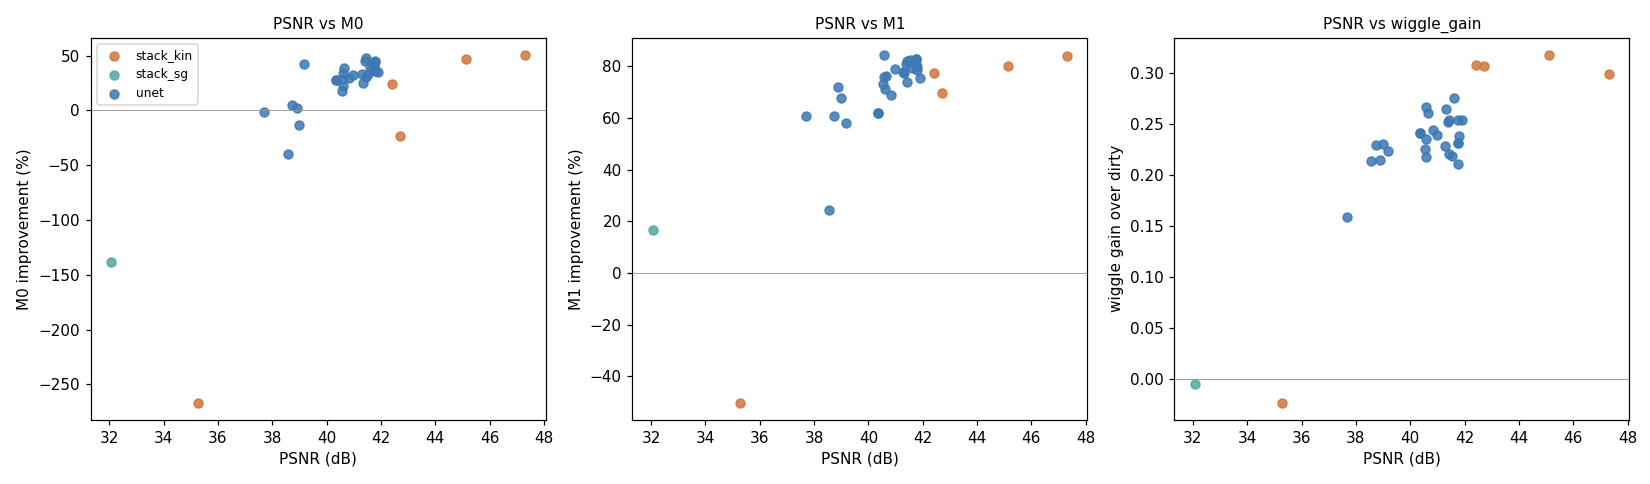

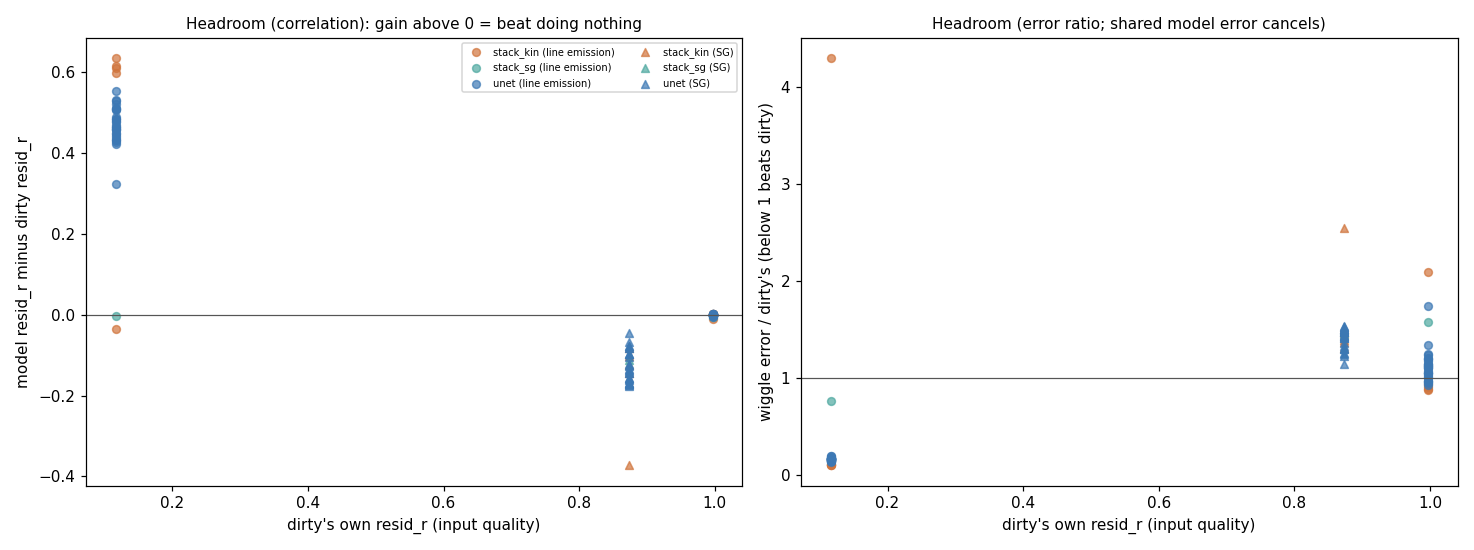

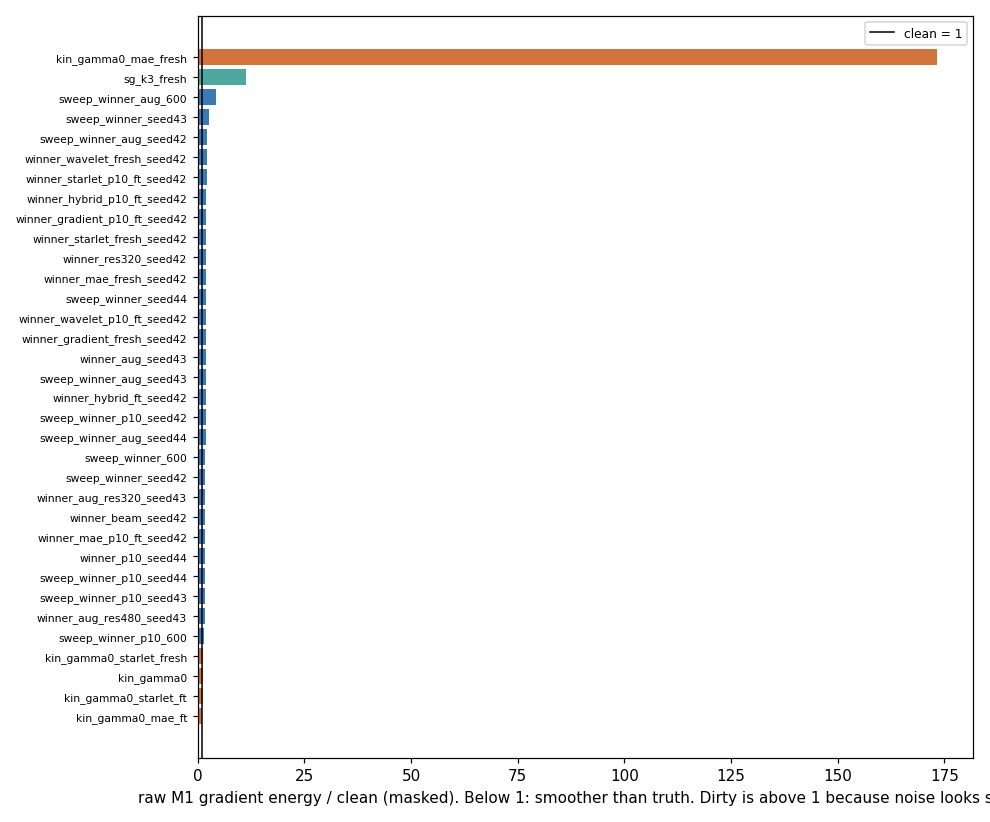

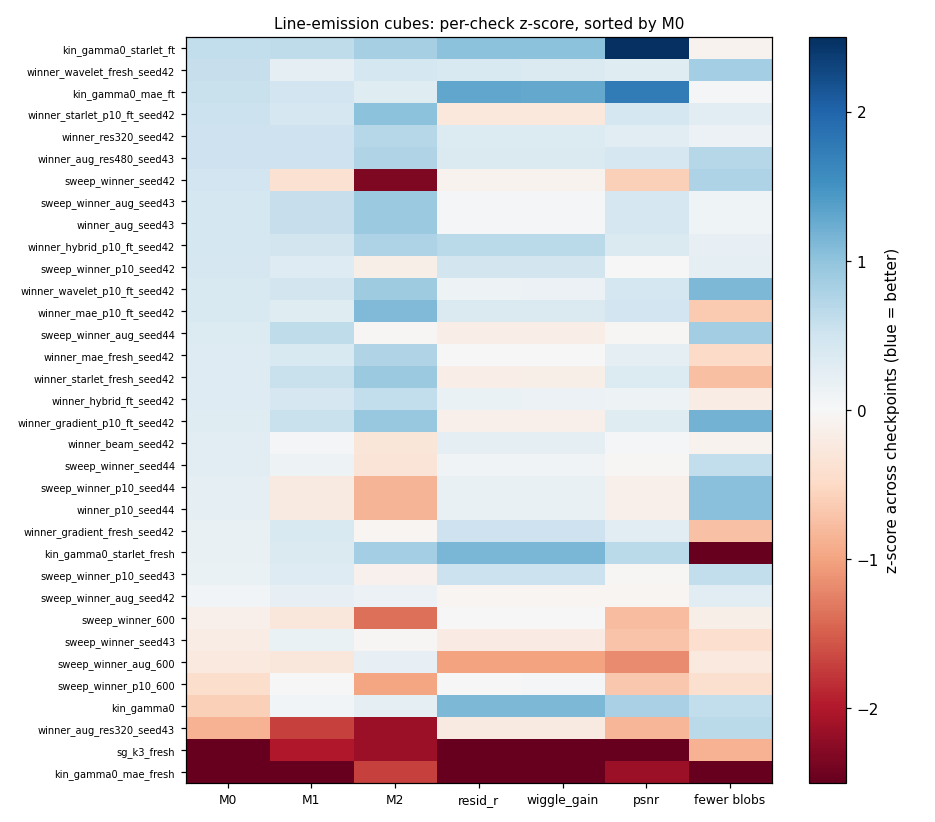

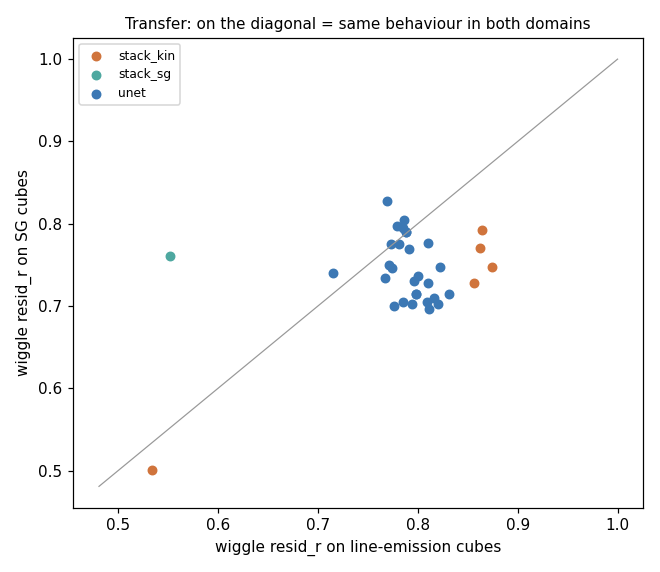

In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
FAM = {'unet': '#3C78B4', 'stack_kin': '#D0743C', 'stack_sg': '#4EA8A0', 'stack': '#8E6CC0', 'ddpm': '#C75E8A'}
fig_paths = []

def save(fig, name):
    p = os.path.join(WORK, name); fig.tight_layout(); fig.savefig(p, dpi=110); plt.close(fig); fig_paths.append(p); return p

if le is not None:
    # (a) PSNR does not rank: PSNR against M0 and against the wiggle
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
    for j, (m, t) in enumerate([('M0', 'M0 improvement (%)'), ('M1', 'M1 improvement (%)'), ('wiggle_gain', 'wiggle gain over dirty')]):
        for fam, d in le.groupby('family'):
            ax[j].scatter(d['psnr'], d[m], s=34, color=FAM.get(fam, '#888'), label=fam, alpha=.85)
        ax[j].set_xlabel('PSNR (dB)'); ax[j].set_ylabel(t); ax[j].axhline(0, color='#999', lw=.6)
        ax[j].set_title(f'PSNR vs {m}', fontsize=10)
    ax[0].legend(fontsize=8)
    save(fig, 'nb16_psnr_vs_moments.png')

    # (b) headroom: model gain against how degraded the input already was, one point per (checkpoint, cube). BOTH domains:
    # the SG cubes are where the "models lose when dirty is already good" thesis lives. Failed geometry fits are already NaN.
    d = ok[ok.dirty_resid_r.notna() & ok.wiggle_gain.notna()]
    fig, ax = plt.subplots(1, 2, figsize=(13.4, 5))
    for a_, (xcol, ycol, xl, yl, tt) in zip(ax, [('dirty_resid_r', 'wiggle_gain', "dirty's own resid_r (input quality)", 'model resid_r minus dirty resid_r',
                                                 'Headroom (correlation): gain above 0 = beat doing nothing'),
                                                ('dirty_resid_r', 'resid_err_ratio', "dirty's own resid_r (input quality)", "wiggle error / dirty's (below 1 beats dirty)",
                                                 'Headroom (error ratio; shared model error cancels)')]):
        for dom, mk_ in (('line_emission', 'o'), ('sg', '^')):
            for fam, g in d[d.domain == dom].groupby('family'):
                a_.scatter(g[xcol], g[ycol], s=26, marker=mk_, color=FAM.get(fam, '#888'), alpha=.7, label=f'{fam} ({"line emission" if dom == "line_emission" else "SG"})')
        a_.axhline(1 if ycol == 'resid_err_ratio' else 0, color='#555', lw=.8)
        a_.set_xlabel(xl); a_.set_ylabel(yl); a_.set_title(tt, fontsize=10)
    ax[0].legend(fontsize=6.5, ncol=2)
    save(fig, 'nb16_headroom.png')

    # (c) sharpness: is the smoothing real?
    t = le.sort_values('gradE_ratio')
    fig, ax = plt.subplots(figsize=(9, max(4, .22 * len(t))))
    ax.barh(t.index, t['gradE_ratio'], color=[FAM.get(f, '#888') for f in t['family']])
    ax.axvline(1.0, color='k', lw=1, label='clean = 1'); ax.legend(fontsize=8)
    ax.set_xlabel('raw M1 gradient energy / clean (masked). Below 1: smoother than truth. Dirty is above 1 because noise looks sharp.')
    ax.tick_params(axis='y', labelsize=7)
    save(fig, 'nb16_sharpness.png')

    # (d) heatmap of z-scored checks: which checkpoint is good at what
    cols = ['M0', 'M1', 'M2', 'resid_r', 'wiggle_gain', 'psnr']
    z = (le[cols] - le[cols].mean()) / le[cols].std().replace(0, 1)
    z['fewer blobs'] = -(le['invented_blobs'] - le['invented_blobs'].mean()) / (le['invented_blobs'].std() or 1)
    z = z.sort_values('M0', ascending=False)
    fig, ax = plt.subplots(figsize=(8.5, max(4, .22 * len(z))))
    im = ax.imshow(z.values, cmap='RdBu', vmin=-2.5, vmax=2.5, aspect='auto')
    ax.set_xticks(range(len(z.columns))); ax.set_xticklabels(z.columns, fontsize=8)
    ax.set_yticks(range(len(z))); ax.set_yticklabels(z.index, fontsize=6.5)
    fig.colorbar(im, ax=ax, label='z-score across checkpoints (blue = better)')
    ax.set_title('Line-emission cubes: per-check z-score, sorted by M0', fontsize=10)
    save(fig, 'nb16_heatmap.png')

if le is not None and sg is not None:
    # (e) transfer: the same checkpoint on line-emission cubes against on SG cubes
    both = le[['resid_r', 'M1']].join(sg[['resid_r', 'M1']], lsuffix='_le', rsuffix='_sg', how='inner').join(le['family'])
    if len(both):
        fig, ax = plt.subplots(figsize=(6, 5.2))
        for fam, g in both.groupby('family'):
            ax.scatter(g['resid_r_le'], g['resid_r_sg'], s=30, color=FAM.get(fam, '#888'), label=fam)
        lim = [min(both.resid_r_le.min(), both.resid_r_sg.min()) - .02, 1.0]
        ax.plot(lim, lim, color='#999', lw=.8)
        ax.set_xlabel('wiggle resid_r on line-emission cubes'); ax.set_ylabel('wiggle resid_r on SG cubes')
        ax.set_title('Transfer: on the diagonal = same behaviour in both domains', fontsize=10); ax.legend(fontsize=8)
        save(fig, 'nb16_transfer.png')

for p in fig_paths: display(Image(p))

## 6b. Every checkpoint, as images

Built from the maps saved for each checkpoint (`nb16_maps/`). For each case: **M0 / M1 / M2 sheets**, **error maps**
(denoised minus clean, scaled by dirty's own error), the **wiggle residual** (the Keplerian-subtracted M1 itself) as a contact
sheet of every checkpoint AND as the classic two-row figure (M1 above, residual below, RMS in each title) for every checkpoint, 5 per page with clean
and dirty repeated on each page,
**blue / systemic / red channel** sheets and the systemic-channel error, an **M1 sharpness** sheet, an
**invented-structure** sheet, **line profiles**, an **M0 radial profile and M1 power spectrum**, and a large **top-K
detail** figure. Across the run: the score tables as images, a scoreboard of every metric, the loss x source matrix, and a
checkpoint x cube heatmap. Tiles are ordered best M0 first; every tile has its number in its title.

In [10]:
from src.evaluation import checkpoint_figures as cf
all_paths = cf.build_all(MAP_DIR, ok, WORK, figure_cases=FIGURE_CASES)
print(f'\n{len(all_paths)} figure(s) written to {WORK}')

  run_0002_00560_rt_00: 34 checkpoint(s) -> 26 figure(s)
  run_0002_00560_rt_01: 34 checkpoint(s) -> 26 figure(s)
  sg_v2: 34 checkpoint(s) -> 26 figure(s)

84 figure(s) written to /kaggle/working


nb16_loss_x_source.png


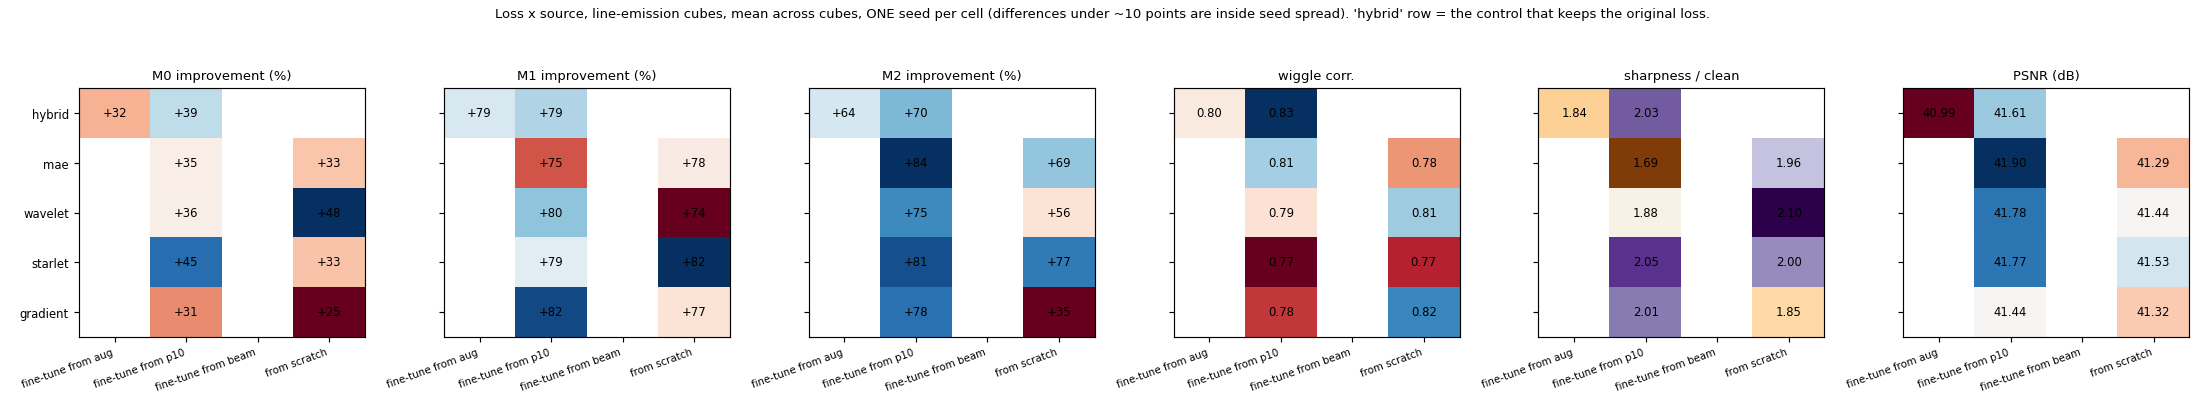

nb16_per_cube.png


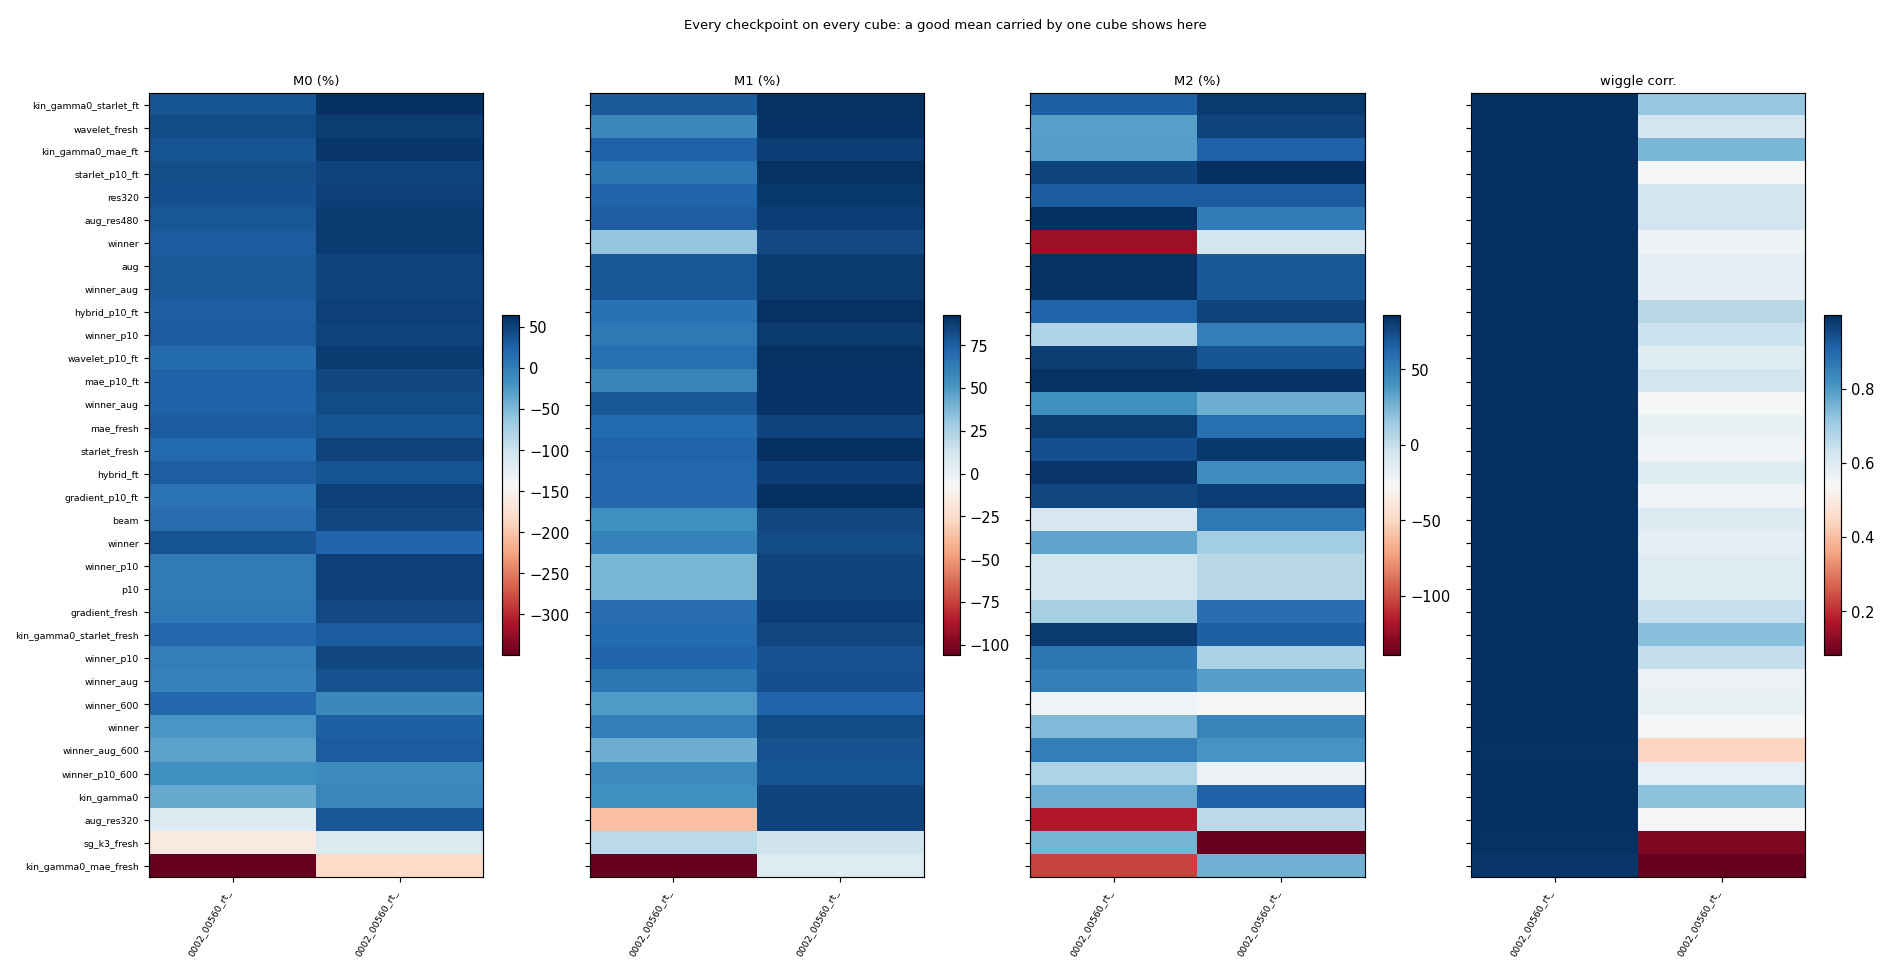

nb16_scoreboard_line_emission.png


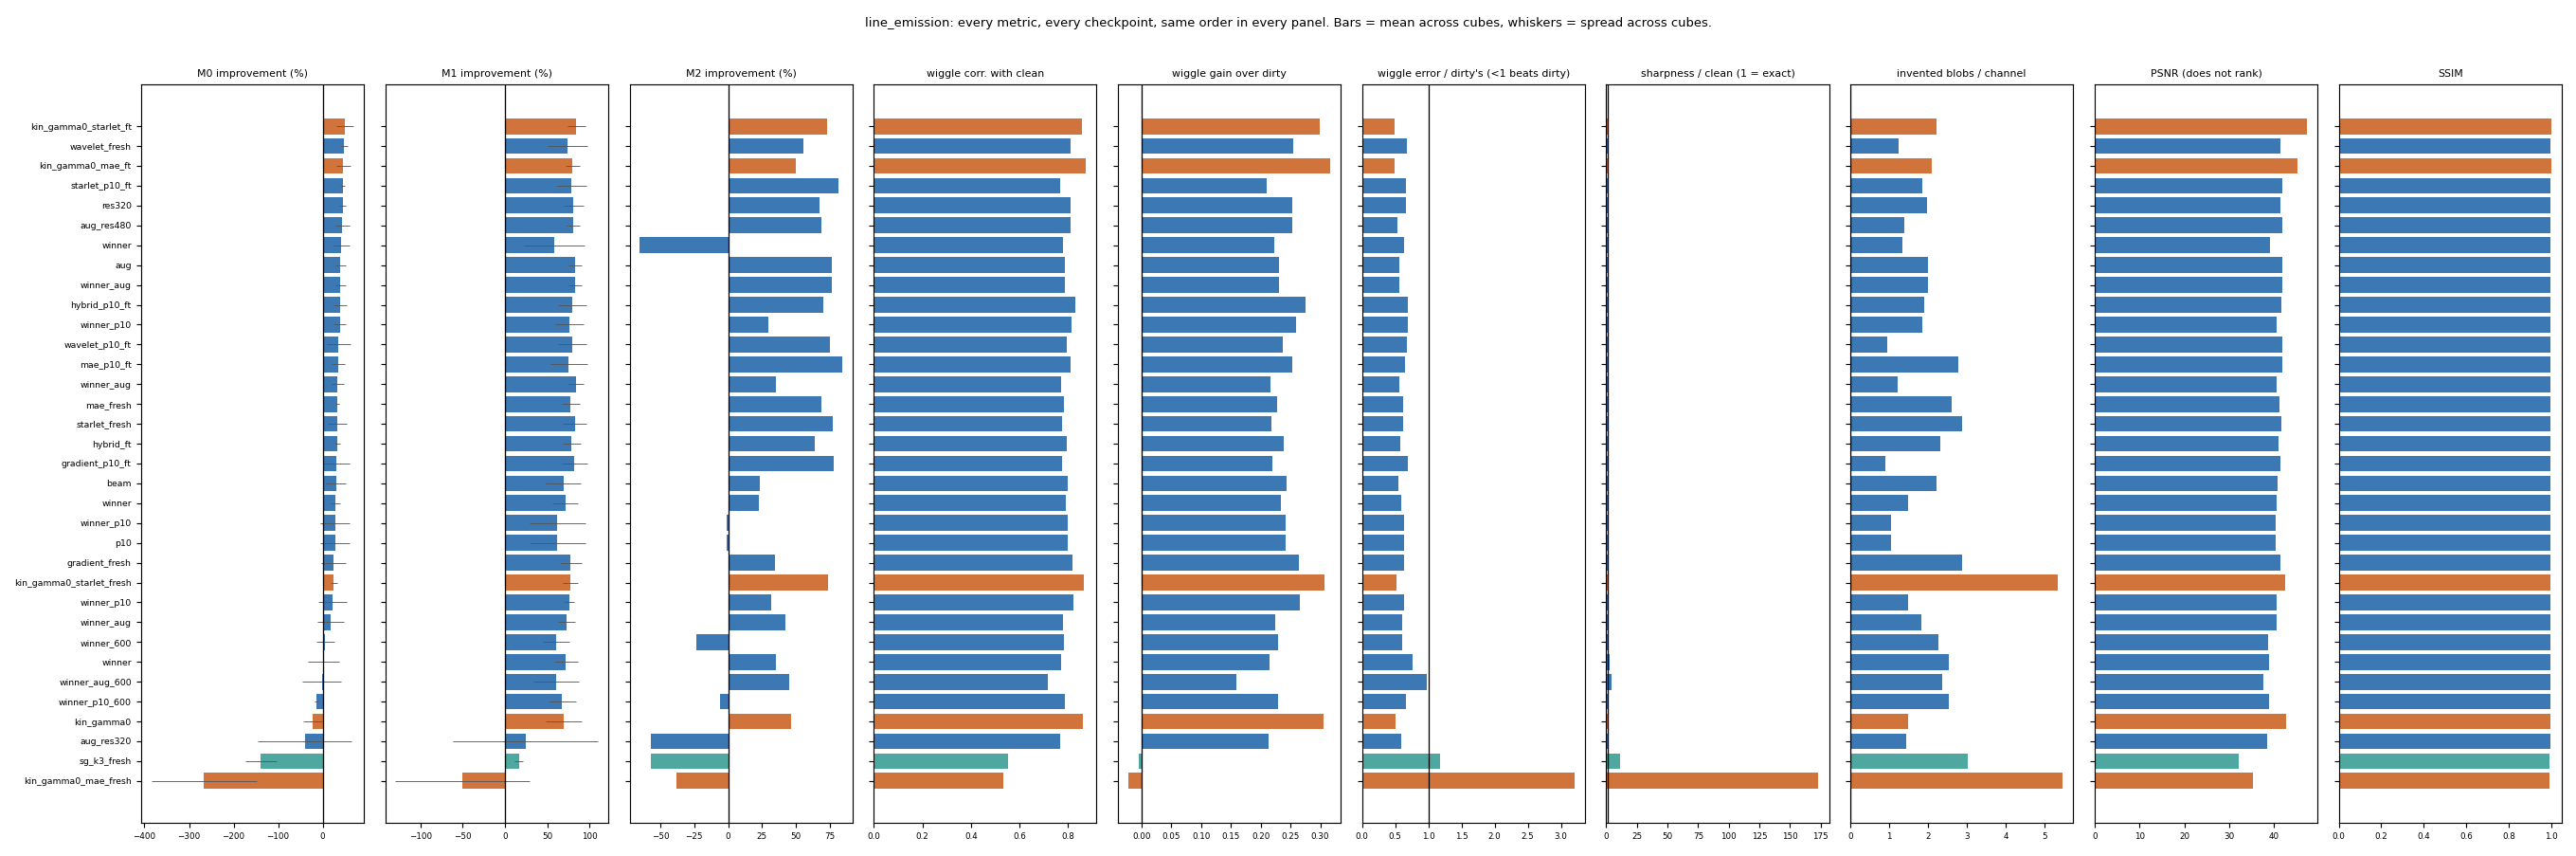

nb16_scoreboard_sg.png


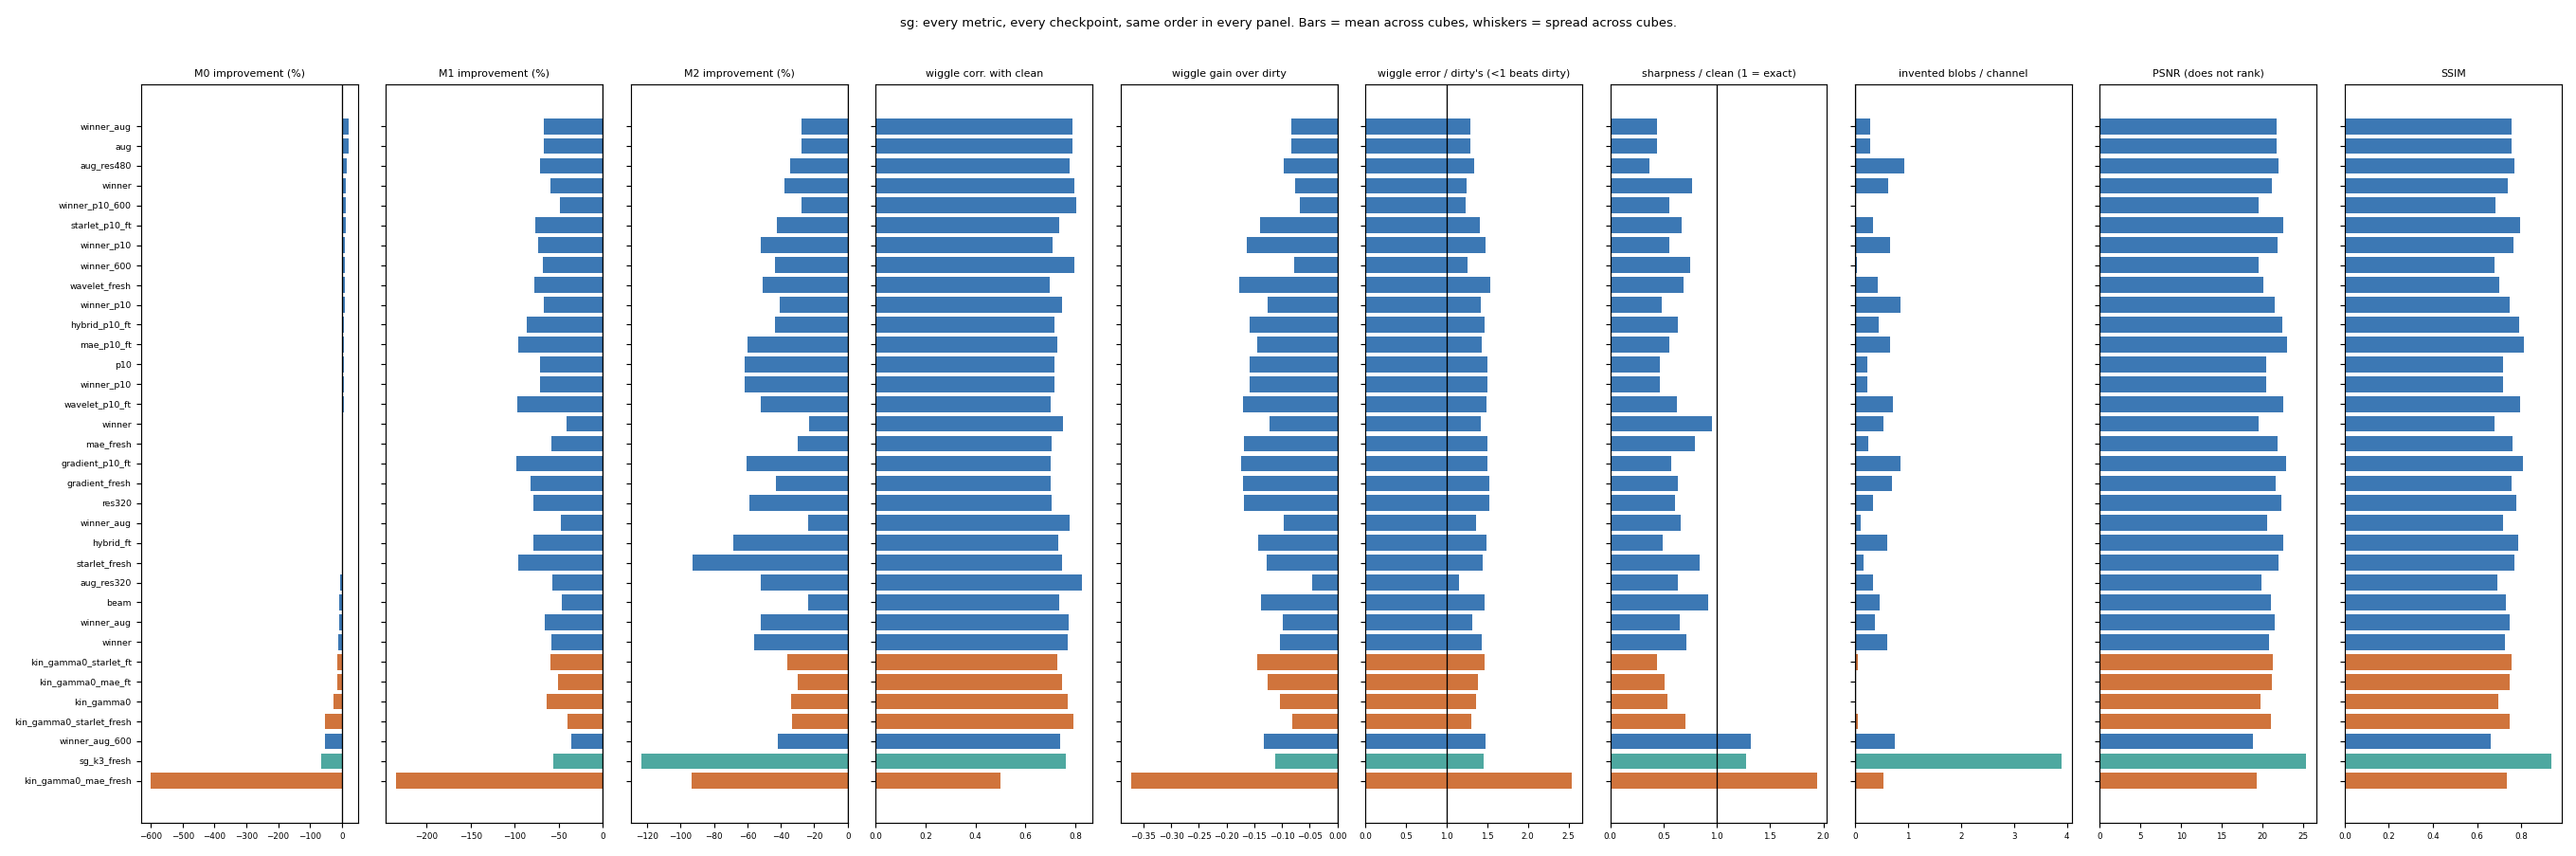

nb16_table_line_emission.png


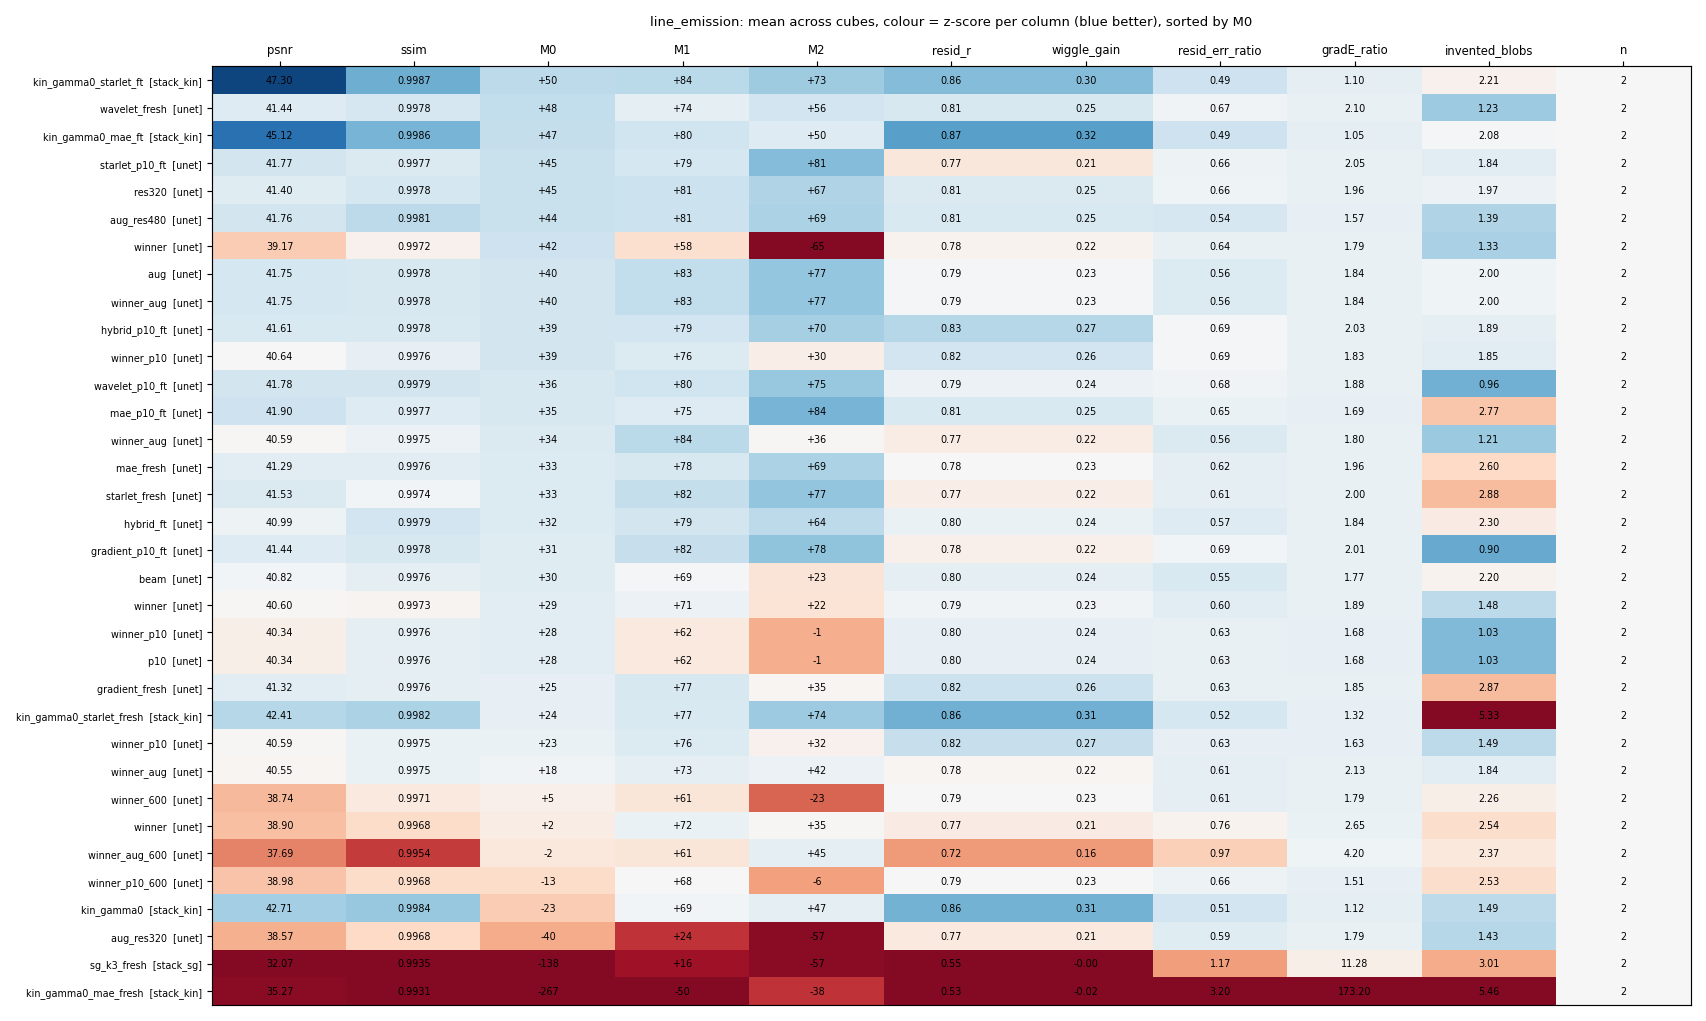

nb16_table_sg.png


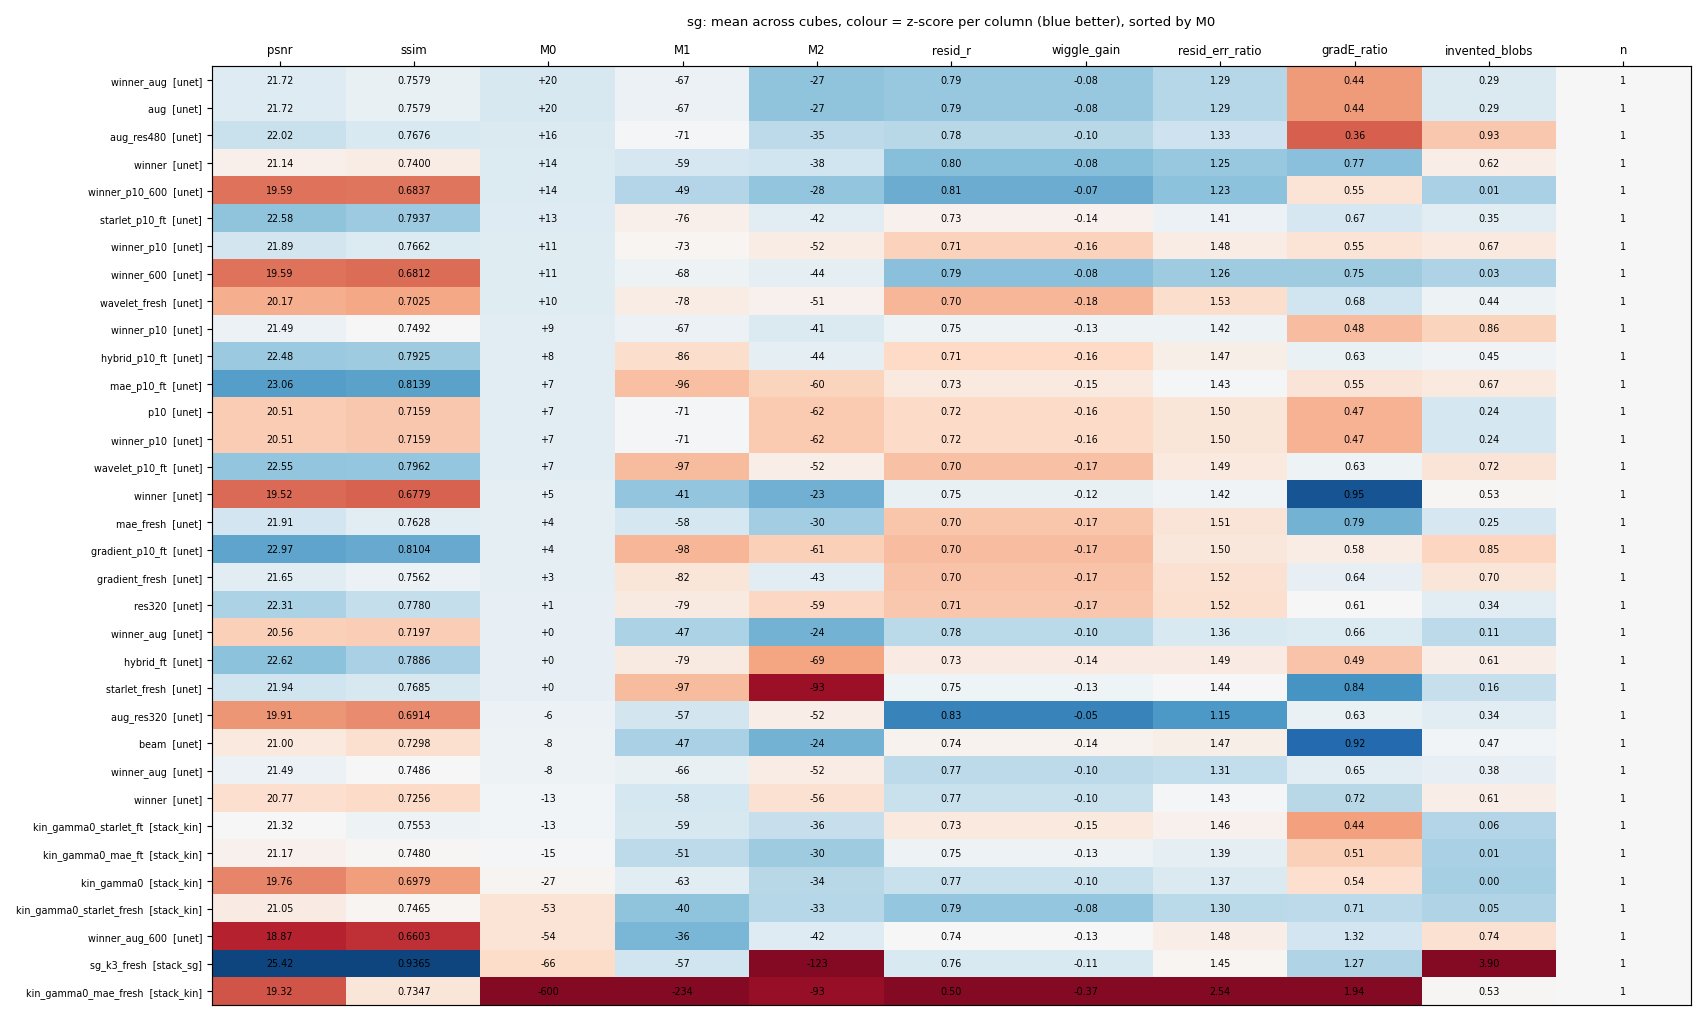

AttributeError: 'NoneType' object has no attribute 'group'

In [11]:
# Show the dashboards and, for each case, the figures that answer the main questions. Everything else is in the Output.
def show(pattern, limit=None):
    ps = sorted(p for p in all_paths if re.search(pattern, os.path.basename(p)))
    for p in ps[:limit]:
        print(os.path.basename(p)); display(Image(p))

show(r'nb16_(table|scoreboard|loss_x_source|per_cube)')
for case in sorted({re.match(r'nb16_sheet_(.+?)_(M0|M1|M2|err|wiggle|chan|sharpness|invented|spectra|radial|topk)', os.path.basename(p)).group(1)
                    for p in all_paths if 'nb16_sheet_' in os.path.basename(p)}):
    print(f'\n########## {case}')
    show(rf'nb16_sheet_{re.escape(case)}_(topk|M1|err_M1|wiggle|wiggle_classic_p\d+|chan1|sharpness|invented|spectra|radial_power)\.png')

## 7. Collect outputs

In [ ]:
from src.evaluation.collect_outputs import collect_outputs

_run_dir = collect_outputs(
    '16-checkpoint-evaluation',
    ['nb16_eval_rows.csv', 'nb16_inventory.csv', 'nb16_*.png'],
    extra={'profile': PROFILE, 'n_checkpoints': len(specs), 'n_rows': int(len(ok)) if 'ok' in dir() else 0,
           'cases': sorted(ok.case.unique().tolist()) if 'ok' in dir() else [],
           'validated': 'run_0002_00560_rt_00 winner_aug_seed43 M0 +31.3 M1 +77.2 M2 +84.6 == published v20'},
)
print('\nAnything listed as NOT FOUND above did not get written this run.')